# JWST MIRI Photometry Extraction & Visualization

## Read the data

In [21]:
from astropy.io import fits

# 1. Open the file 
file_path = 'images/cos87259_F770W_cut.fits'
hdul = fits.open(file_path)

# 2. View the overall structure of HDUs in this file
print("File Information:")
hdul.info()
print("-" * 40)

# 3. Access a specific Extension (e.g., 'SCI' for Science)
sci_header = hdul['SCI'].header
sci_data = hdul['SCI'].data

# 4. Read the first 10 lines of the Header to understand metadata
print("First 10 Header Keywords:")
print(list(sci_header.items())[:10])
print("-" * 40)

# 5. Check the shape of the Data array
# For 3D IFU Spectra, it's (Wavelength, Y_Pixels, X_Pixels)
print("Data Shape:", sci_data.shape)

# Close the file when done to save memory
hdul.close()

File Information:
Filename: images/cos87259_F770W_cut.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  SCI           1 PrimaryHDU      74   (166, 166)   float32   
  1  MASK          1 ImageHDU         8   (166, 166)   uint8   
  2  SIGMA         1 ImageHDU         8   (166, 166)   float32   
----------------------------------------
First 10 Header Keywords:
[('SIMPLE', True), ('BITPIX', -32), ('NAXIS', 2), ('NAXIS1', 166), ('NAXIS2', 166), ('EXTEND', True), ('EXTNAME', 'SCI'), ('MJD-BEG', 60774.194085627314), ('MJD-AVG', 60774.196775516204), ('MJD-END', 60774.199481331016)]
----------------------------------------
Data Shape: (166, 166)


In [22]:
import numpy as np
from astropy.io import fits
from astropy import wcs
import sep
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

miri_dir = 'images'
output_dir = 'photometry'
os.makedirs(output_dir, exist_ok=True)
clump_ids = ['Center', 'West', 'North', 'South', 'Southeast']

'''
# Define clump parameters from the original notebook

x_ifu = np.array([27.2994, 27.2994, 27.5317, 26.9051, 19.7599]) 
y_ifu = np.array([24.2436, 24.2436, 28.4938, 15.3950, 20.7517]) 
a_ifu = np.array([2.0362, 2.0362, 1.4309, 3.2745, 2.0370]) 
b_ifu = np.array([1.4896, 1.4896, 1.3812, 1.0209, 1.0339]) 
r_ifu = np.array([2.6471, 2.6471, 3.2883, 2.5689, 2.2962]) 
theta_ifu = np.array([-0.1644, -0.1644, -0.0619, -0.3366, 0.9059]) 
'''

'\n# Define clump parameters from the original notebook\n\nx_ifu = np.array([27.2994, 27.2994, 27.5317, 26.9051, 19.7599]) \ny_ifu = np.array([24.2436, 24.2436, 28.4938, 15.3950, 20.7517]) \na_ifu = np.array([2.0362, 2.0362, 1.4309, 3.2745, 2.0370]) \nb_ifu = np.array([1.4896, 1.4896, 1.3812, 1.0209, 1.0339]) \nr_ifu = np.array([2.6471, 2.6471, 3.2883, 2.5689, 2.2962]) \ntheta_ifu = np.array([-0.1644, -0.1644, -0.0619, -0.3366, 0.9059]) \n'

In [23]:
'''
# We need the WCS from the IFU to map these pixel coordinates to Sky coordinates
ifu_file = 'd:/Fudan_University/Research/JWST/NIRSpec_IFU/COS-87259_NOBG_prism-clear_s3d.fits'
ifu_hdul = fits.open(ifu_file)
ifu_wcs = wcs.WCS(ifu_hdul['SCI'].header).celestial


# Convert IFU pixel coordinates to sky coordinates (RA, Dec)
ra_clumps, dec_clumps = ifu_wcs.pixel_to_world_values(x_ifu, y_ifu)
'''

bands = ['F560W', 'F770W', 'F1000W', 'F1130W', 'F1280W', 'F1500W', 'F1800W', 'F2100W', 'F2550W']
results = []

## Extracting and Visualizing Apertures for All 9 Bands


Processing MIRI band: F560W


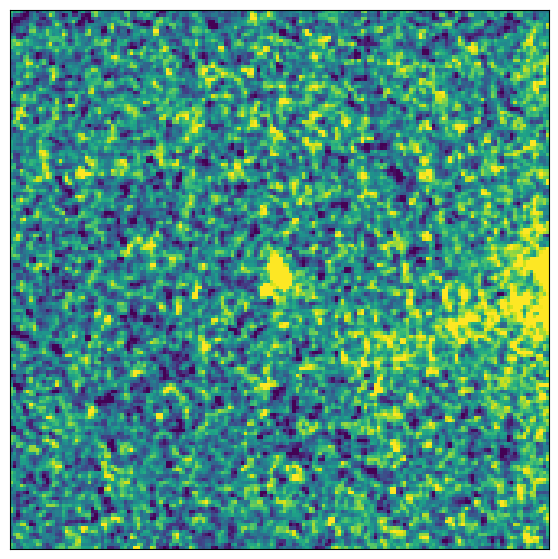


Processing MIRI band: F770W


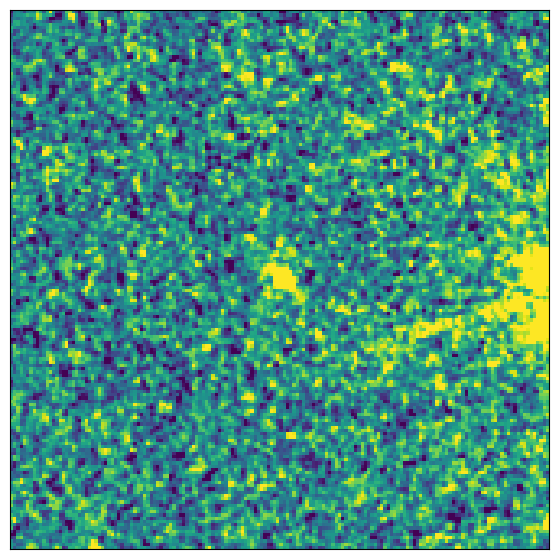


Processing MIRI band: F1000W


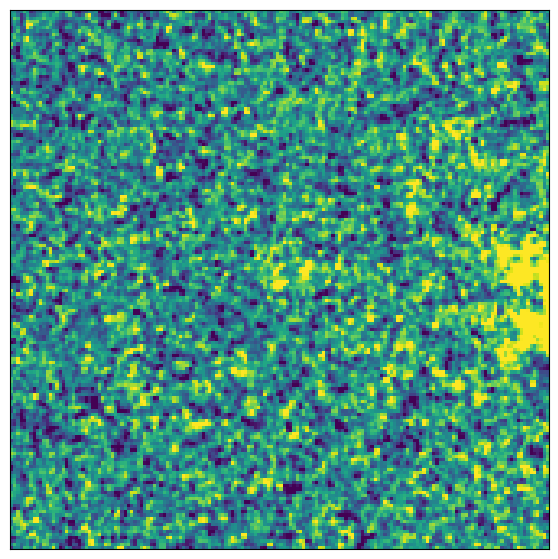


Processing MIRI band: F1130W


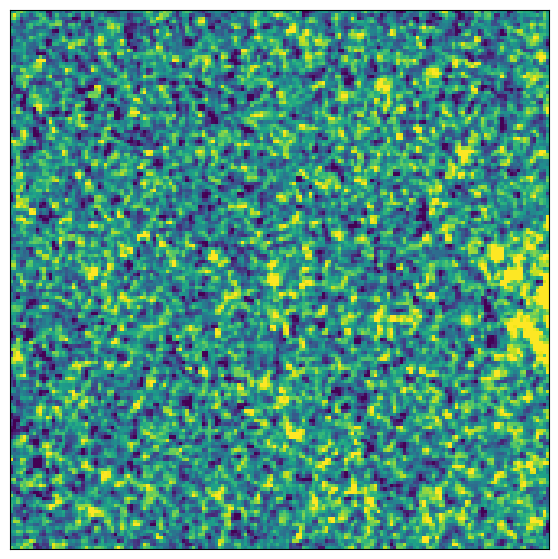


Processing MIRI band: F1280W


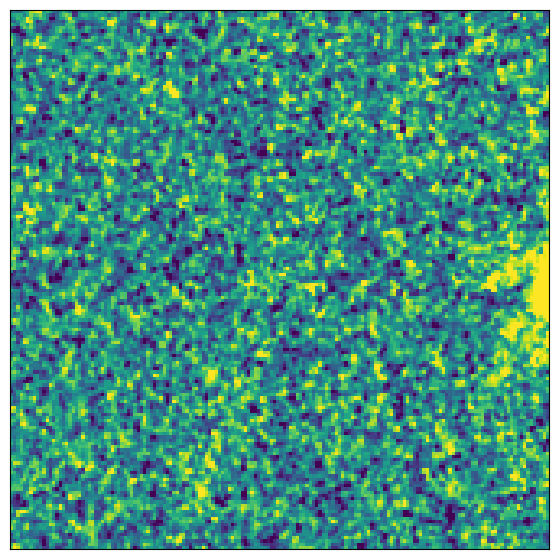


Processing MIRI band: F1500W


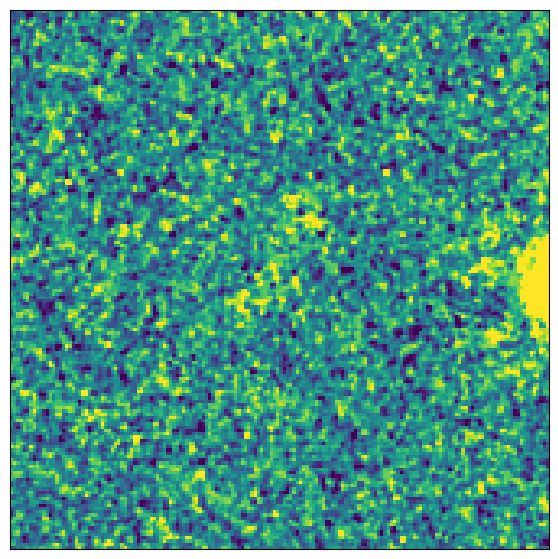


Processing MIRI band: F1800W


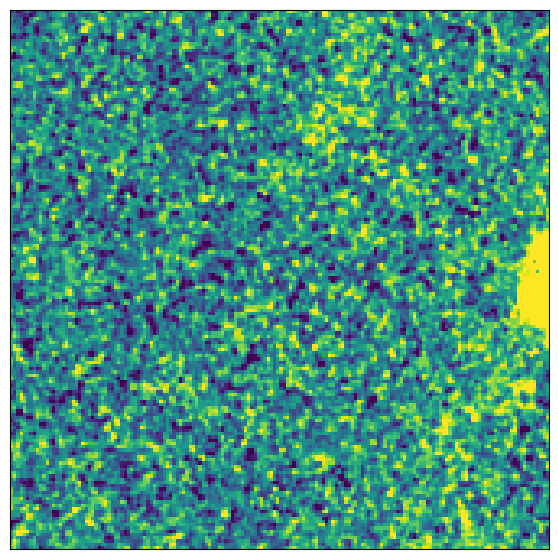


Processing MIRI band: F2100W


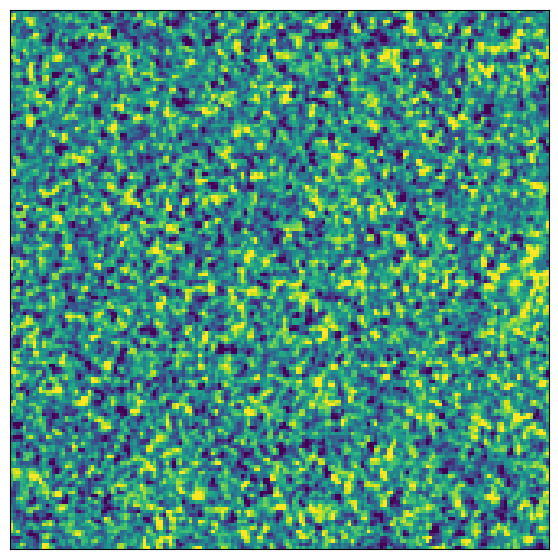


Processing MIRI band: F2550W


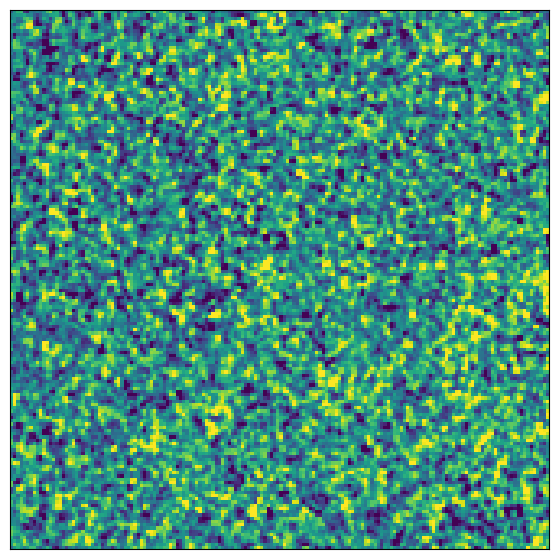

In [28]:
import warnings
warnings.filterwarnings('ignore') # Ignore some FITS WCS warnings for clean output

for band in bands:
    print(f"\nProcessing MIRI band: {band}")
    file_path = os.path.join(miri_dir, f'cos87259_{band}_cut.fits')
    
    if not os.path.exists(file_path):
        print(f"  Warning: File not found: {file_path}")
        continue
        
    with fits.open(file_path) as hdul:
        sci_data = hdul['SCI'].data
        #err_data = hdul['ERR'].data
        header = hdul['SCI'].header
        
        miri_wcs = wcs.WCS(header)
        pixar_sr = header.get('PIXAR_SR', 1.0)
        
        '''
        # Find pixel coordinates in MIRI image for each clump
        x_miri, y_miri = miri_wcs.world_to_pixel_values(ra_clumps, dec_clumps)
        
        
        # Scale the aperture sizes from IFU pixels to MIRI pixels
        ifu_scale = np.sqrt(ifu_wcs.pixel_scale_matrix[0,0]**2 + ifu_wcs.pixel_scale_matrix[0,1]**2)
        miri_scale = np.sqrt(miri_wcs.pixel_scale_matrix[0,0]**2 + miri_wcs.pixel_scale_matrix[0,1]**2)
        scale_factor = ifu_scale / miri_scale
        
        a_miri = a_ifu * scale_factor
        b_miri = b_ifu * scale_factor
        r_miri = r_ifu 
        '''
        
        sci_data = sci_data.astype(sci_data.dtype.newbyteorder('='))
        #err_data = err_data.astype(err_data.dtype.newbyteorder('='))
        
        nan_mask = np.isnan(sci_data)
        sci_data_clean = np.nan_to_num(sci_data, nan=0.0)
        #err_data_clean = np.nan_to_num(err_data, nan=np.inf)
        
        # Plotting Setup
        plt.figure(figsize=(7, 7))
        m = np.nanmedian(sci_data)
        s = np.nanstd(sci_data)
        plt.imshow(sci_data_clean, origin='lower', vmin=m-2*s, vmax=m+2*s, cmap='viridis')
        
        '''
        # Zoom in to the clumps
        cx, cy = np.mean(x_miri), np.mean(y_miri)
        zoom = 20 * scale_factor # roughly 50 IFU pixels
        lt.xlim(cx - zoom, cx + zoom)
        plt.ylim(cy - zoom, cy + zoom)
        plt.title(f"MIRI Band {band} w/ Elliptical Apertures")
        
        for n, clump_id in enumerate(clump_ids):
            aper_flux, aper_flux_err, aper_flag = sep.sum_ellipse(
                sci_data_clean, [x_miri[n]], [y_miri[n]], [a_miri[n]], [b_miri[n]], [theta_ifu[n]], [r_miri[n]], 
                err=err_data_clean, mask=nan_mask
            )
            
            # Convert to microJansky (uJy)
            flux_ujy = aper_flux[0] * 1e6 * pixar_sr * 1e6 # MJy/sr -> Jy -> uJy
            flux_err_ujy = aper_flux_err[0] * 1e6 * pixar_sr * 1e6
            wl_obs = float(band.replace('W', '').replace('F', '')) / 100.0 # um
            
            res_dict = {
                'Clump ID': clump_id,
                'Band': band,
                'Wavelength_um': wl_obs,
                'Flux_uJy': flux_ujy,
                'Flux_Err_uJy': flux_err_ujy
            }
            results.append(res_dict)
            print(f"    {clump_id}: Flux={flux_ujy:.2f} uJy")
            
            
            # Draw Aperture
            e = Ellipse(xy=(x_miri[n], y_miri[n]), width=2.*a_miri[n]*r_miri[n], height=2.*b_miri[n]*r_miri[n], 
                        angle=theta_ifu[n]*180./np.pi, facecolor='none', edgecolor='red', lw=1.5)
            plt.gca().add_patch(e)
            #plt.text(x_miri[n] + 1.5, y_miri[n] + 1.5, clump_id, color='red', fontsize=10)
        '''
            
        plt.xticks([])
        plt.yticks([])
        plt.show()

## Saving Results

In [ ]:
# Save results
df = pd.DataFrame(results)
output_file = os.path.join(output_dir, 'miri_photometry.csv')
df.to_csv(output_file, index=False)
print(f"Extraction complete. Results saved to {output_file}")

## Photometric flux

MIRI SED plot saved to d:/Fudan_University/Research/JWST/extracted_photometry\miri_seds.png


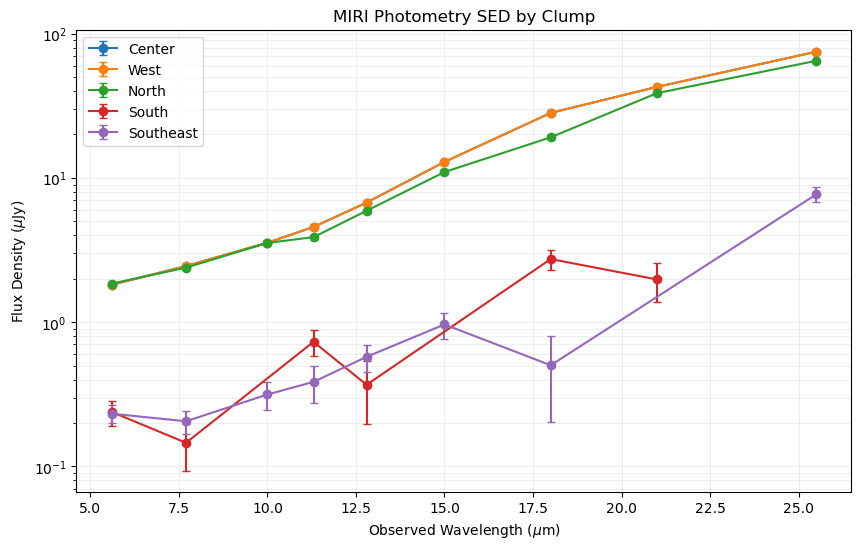

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

miri_file = 'd:/Fudan_University/Research/JWST/extracted_photometry/miri_photometry.csv'
output_dir = 'd:/Fudan_University/Research/JWST/extracted_photometry'

if not os.path.exists(miri_file):
    print("MIRI photometry file not found.")
    exit()

df = pd.read_csv(miri_file)

clumps = df['Clump ID'].unique()

plt.figure(figsize=(10, 6))

# Plot SED for each clump
for clump in clumps:
    clump_data = df[df['Clump ID'] == clump].sort_values(by='Wavelength_um')
    
    # Filter out pure 0 or negative fluxes for log scale plot
    valid_data = clump_data[clump_data['Flux_uJy'] > 0]
    
    plt.errorbar(
        valid_data['Wavelength_um'], 
        valid_data['Flux_uJy'], 
        yerr=valid_data['Flux_Err_uJy'], 
        label=clump, 
        marker='o', 
        linestyle='-',
        capsize=3
    )

#plt.xscale('log')
plt.yscale('log')
plt.xlabel('Observed Wavelength ($\mu$m)')
plt.ylabel('Flux Density ($\mu$Jy)')
plt.title('MIRI Photometry SED by Clump')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

output_plot = os.path.join(output_dir, 'miri_seds.png')
plt.savefig(output_plot, dpi=300)
print(f"MIRI SED plot saved to {output_plot}")
